Columns in metadata.csv: ['slice_file_name', 'fsID', 'start', 'end', 'road', 'classID', 'class']
Sample metadata rows: [{'slice_file_name': 'Around Arya School(1°16_32_ S 36°49_29_ E)--1-0.wav', 'fsID': 'Around Arya School(1°16_32_ S 36°49_29_ E)', 'start': 0.0, 'end': 6.0, 'road': 'Around Arya School(1°16_32_ S 36°49_29_ E)', 'classID': 7, 'class': 'heavy truck'}, {'slice_file_name': 'Around Arya School(1°16_32_ S 36°49_29_ E)--1-1.wav', 'fsID': 'Around Arya School(1°16_32_ S 36°49_29_ E)', 'start': 6.0, 'end': 12.0, 'road': 'Around Arya School(1°16_32_ S 36°49_29_ E)', 'classID': 1, 'class': 'motorcycle'}, {'slice_file_name': 'Around Arya School(1°16_32_ S 36°49_29_ E)--1-2.wav', 'fsID': 'Around Arya School(1°16_32_ S 36°49_29_ E)', 'start': 12.0, 'end': 18.0, 'road': 'Around Arya School(1°16_32_ S 36°49_29_ E)', 'classID': 1, 'class': 'motorcycle'}, {'slice_file_name': 'Around Arya School(1°16_32_ S 36°49_29_ E)--1-3.wav', 'fsID': 'Around Arya School(1°16_32_ S 36°49_29_ E)', 'start

c:\Users\USER\Music\SonusAI\venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


Excel locations: ['LANGATA LINK ROAD' 'RAILA ODINGA ROAD NEXT TO TOTAL' 'NYAYO LANGATA'
 'LIKONI ROAD' 'WINNERS CHAPEL(LIKONI ROAD)' 'LANGATA HOSPITAL' 'MMU'
 'KAREN C SCHOOL' 'JUNCTION MALL' nan 'UHURU PARK' 'JEVANJEE'
 'ARYA(NGARA)' 'OLA ENERGY WAIYAKI WAY' 'KANGEMI' 'KINOO'
 'SOUTHERN BYPASS 1' 'SOUTHERN BYPASS 2' 'NGONG ROAD' 'KAWANGWARE'
 'ICD ROAD' 'IMAARA MALL' 'KFC EMBAKASI' 'KCB UTAWALA EASTERN BYPASS'
 'MAKONGENI SHOPPING CENTRE RUAI' 'QUALITY MEAT PACKERS'
 'DAVIS & SHIRTLIFF KANGUNDO ROAD' 'BEE CENTRE' 'TOTAL ENERGIES OUTERING'
 'JOGOO ROAD' 'BBS MALL EASTLEIGH' 'THIKA ROAD(PANGANI)' 'KIAMBU ROAD'
 'RUNDA' 'RUAKA' 'KIAMBU ROAD 2' 'THOME' 'NORTHERN BYPASS'
 'OPP. KU HOSPITAL' 'NORTHERN BYPASS 2' 'THIKA ROAD 1' 'THIKA ROAD 2'
 'AROUND BABA DOGO ROAD']


c:\Users\USER\Music\SonusAI\venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


Extracted MFCCs shape: (2185, 40, 517)


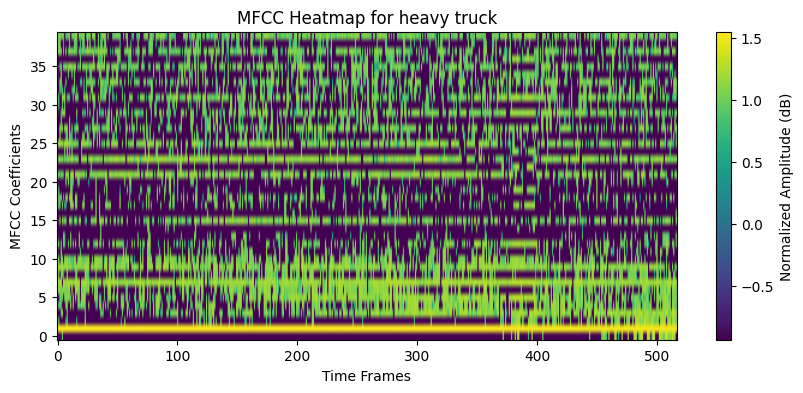

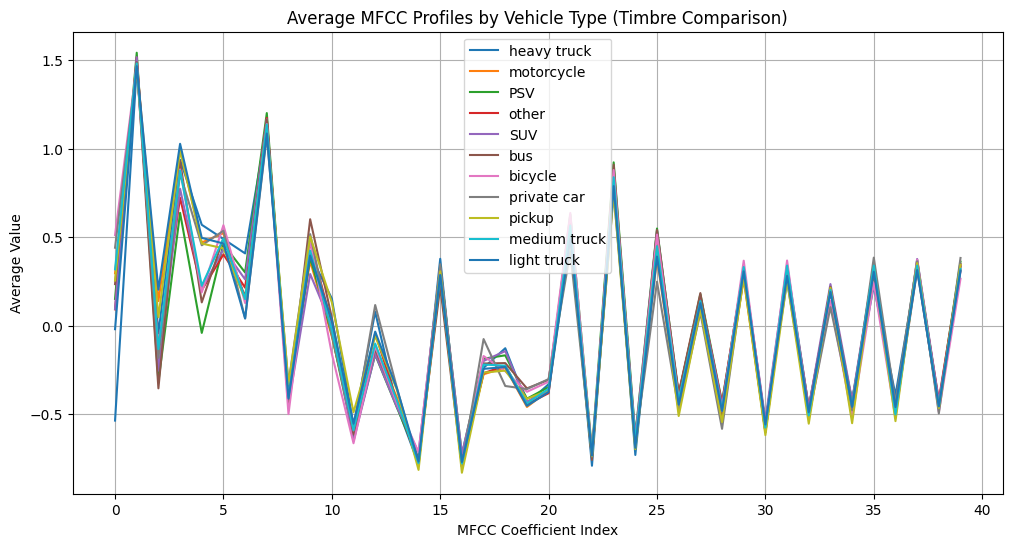


Statistical Summary of MFCCs by Class:
                          heavy truck    motorcycle           PSV  \
Mean                     1.046237e-08 -7.161133e-10 -7.395031e-10   
Std Dev                  9.999757e-01  9.999758e-01  9.999760e-01   
Spectral Flatness (Avg)  9.748693e-01  9.726658e-01  9.695528e-01   

                                other           SUV           bus  \
Mean                    -2.731744e-09 -1.248326e-08  7.460509e-09   
Std Dev                  9.999756e-01  9.999758e-01  9.999758e-01   
Spectral Flatness (Avg)  9.716582e-01  9.720929e-01  9.736416e-01   

                              bicycle   private car        pickup  \
Mean                    -3.682902e-09 -3.286797e-08 -2.459508e-09   
Std Dev                  9.999757e-01  9.999759e-01  9.999759e-01   
Spectral Flatness (Avg)  9.756922e-01  9.748911e-01  9.766814e-01   

                         medium truck   light truck  
Mean                    -4.822927e-09  5.699274e-09  
Std Dev              

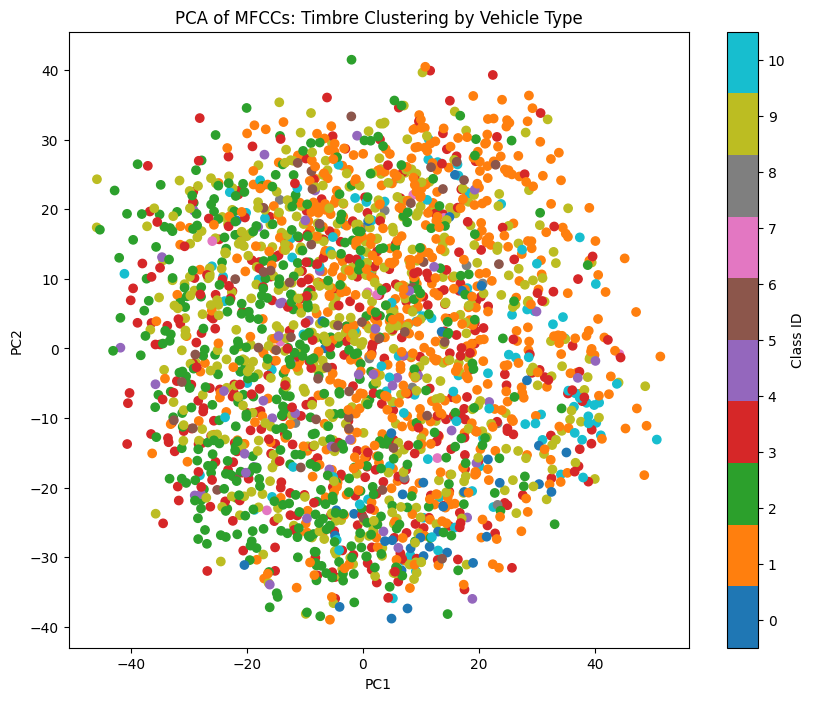


KMeans Clustering (Timbre Groups vs. Class IDs):
Cluster     0    1   2    3   4
Class ID                       
0           3   19   9    3   5
1         224  102  94   58  99
2          72  148  22  174  31
3          79   91  43  119  61
4           9   15   3   13   9
5           3    8   0    5   2
6          12    8   0    6   3
7           6    2   1    1   1
8           4    2   0    0   6
9         157  107  48  123  59
10         27   23  40   13  13


In [3]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import torch
import torchaudio
from torchaudio import transforms
import os
import librosa
import random

# Step 1: Load metadata
download_path = Path('data/DATA/output_chunks')
metadata_file = download_path / 'metadata.csv'
try:
    df = pd.read_csv(metadata_file)
except FileNotFoundError:
    raise FileNotFoundError(f"metadata.csv not found at {metadata_file}")
print("Columns in metadata.csv:", df.columns.tolist())
print("Sample metadata rows:", df.head().to_dict(orient='records'))

# Ensure required columns
required_columns = ['road', 'classID', 'class', 'slice_file_name']
if not all(col in df.columns for col in required_columns):
    missing = [col for col in required_columns if col not in df.columns]
    raise KeyError(f"Missing required columns in metadata.csv: {missing}")

# Create relative_path
if 'relative_path' not in df.columns:
    df['relative_path'] = df['road'].astype(str) + '/' + df['slice_file_name'].astype(str)

# Use Path for platform-specific separators
df['relative_path'] = df['relative_path'].apply(lambda x: str(Path(x)))
df = df[['relative_path', 'classID', 'road', 'class']].copy()
df['road'] = df['road'].str.upper().str.strip()
print("Columns in df after processing:", df.columns.tolist())
print("Sample relative_path values:", df['relative_path'].head().tolist())

# Debug file paths
print("Checking download_path:", download_path)
if not download_path.exists():
    raise FileNotFoundError(f"Directory not found: {download_path}")
available_files = {str(f.relative_to(download_path)) for f in download_path.rglob("*.wav")}
print(f"Found {len(available_files)} WAV files in {download_path}")
missing_files = []
for rel_path in df['relative_path']:
    full_path = download_path / rel_path
    if not full_path.exists():
        missing_files.append(str(full_path))
if missing_files:
    print(f"Error: {len(missing_files)}/{len(df)} files missing, e.g., {missing_files[:5]}")
    print("Please verify the audio files exist in data/DATA/output_chunks/<location_name>/<slice_file_name>.")
else:
    print("All files found in metadata.csv are accessible.")

# Test loading the sample file
sample_file = download_path / "Around Arya School(1°16_32_ S 36°49_29_ E)/Around Arya School(1°16_32_ S 36°49_29_ E)--1-0.wav"
print(f"Testing sample file: {sample_file}")
try:
    sig, sr = torchaudio.load(sample_file)
    print(f"Sample file loaded successfully: {sample_file}, sample rate: {sr}, shape: {sig.shape}")
except Exception as e:
    print(f"Error loading sample file {sample_file}: {e}")

# Load Leq data (optional, included for completeness)
try:
    leq_data = pd.read_excel('data/FINAL DATA.xlsx', sheet_name='Noise Summary From Field')
    leq_data['Place'] = leq_data['Place'].str.upper().str.strip()
    print("Excel locations:", leq_data['Place'].unique())
except FileNotFoundError:
    print("Warning: FINAL DATA.xlsx not found. Skipping Leq data loading.")

# Step 2: Define AudioUtil class
class AudioUtil:
    @staticmethod
    def open(audio_file):
        sig, sr = torchaudio.load(audio_file)
        return (sig, sr)

    @staticmethod
    def rechannel(aud, new_channel):
        sig, sr = aud
        if sig.shape[0] == new_channel:
            return aud
        if new_channel == 1:
            resig = sig[:1, :]
        else:
            resig = torch.cat([sig, sig])
        return (resig, sr)

    @staticmethod
    def resample(aud, newsr):
        sig, sr = aud
        if sr == newsr:
            return aud
        num_channels = sig.shape[0]
        resig = torchaudio.transforms.Resample(sr, newsr)(sig[:1, :])
        if num_channels > 1:
            retwo = torchaudio.transforms.Resample(sr, newsr)(sig[1:, :])
            resig = torch.cat([resig, retwo])
        return (resig, newsr)

    @staticmethod
    def pad_trunc(aud, max_ms):
        sig, sr = aud
        num_rows, sig_len = sig.shape
        max_len = sr // 1000 * max_ms
        if sig_len > max_len:
            sig = sig[:, :max_len]
        elif sig_len < max_len:
            pad_begin_len = random.randint(0, max_len - sig_len)
            pad_end_len = max_len - sig_len - pad_begin_len
            pad_begin = torch.zeros((num_rows, pad_begin_len))
            pad_end = torch.zeros((num_rows, pad_end_len))
            sig = torch.cat((pad_begin, sig, pad_end), 1)
        return (sig, sr)

    @staticmethod
    def time_shift(aud, shift_limit):
        sig, sr = aud
        _, sig_len = sig.shape
        shift_amt = int(random.random() * shift_limit * sig_len)
        return (sig.roll(shift_amt), sr)

    @staticmethod
    def mfcc_feature(aud, n_mfcc=40, n_fft=1024, hop_len=512):
        sig, sr = aud
        mfcc = torchaudio.transforms.MFCC(
            sample_rate=sr,
            n_mfcc=n_mfcc,
            melkwargs={"n_fft": n_fft, "hop_length": hop_len, "n_mels": 64}
        )(sig)
        mfcc_db = torchaudio.transforms.AmplitudeToDB(top_db=80)(mfcc)
        mfcc_db = (mfcc_db - mfcc_db.mean()) / (mfcc_db.std() + 1e-6)
        return mfcc_db

    @staticmethod
    def spectro_augment(spec, max_mask_pct=0.1, n_freq_masks=1, n_time_masks=1):
        _, n_mels, n_steps = spec.shape
        mask_value = spec.mean()
        aug_spec = spec
        freq_mask_param = max_mask_pct * n_mels
        for _ in range(n_freq_masks):
            aug_spec = transforms.FrequencyMasking(freq_mask_param)(aug_spec, mask_value)
        time_mask_param = max_mask_pct * n_steps
        for _ in range(n_time_masks):
            aug_spec = transforms.TimeMasking(time_mask_param)(aug_spec, mask_value)
        return aug_spec

# Step 3: Define SoundDS class
class SoundDS(torch.utils.data.Dataset):
    def __init__(self, df, data_path, train=True):
        self.df = df
        self.data_path = str(data_path)
        self.duration = 4000
        self.sr = 22050
        self.channel = 1
        self.shift_pct = 0.4 if train else 0.0
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        relative_path = self.df.loc[idx, 'relative_path'].lstrip('/')
        audio_file = os.path.join(self.data_path, relative_path)
        if not os.path.exists(audio_file):
            raise FileNotFoundError(f"Audio file not found: {audio_file}")
        class_id = self.df.loc[idx, 'classID']
        aud = AudioUtil.open(audio_file)
        mfcc_feat = AudioUtil.mfcc_feature(aud, n_mfcc=40, n_fft=1024, hop_len=512)
        aug_mfcc = AudioUtil.spectro_augment(mfcc_feat, max_mask_pct=0.1, n_freq_masks=2, n_time_masks=2) if self.train else mfcc_feat
        return aug_mfcc, class_id

# Step 4: Prepare dataset without augmentation
analysis_ds = SoundDS(df, download_path, train=False)

# Step 5: Extract MFCC features for all clips
mfccs_list = []
labels_list = []
for idx in range(len(analysis_ds)):
    try:
        mfcc, class_id = analysis_ds[idx]
        mfccs_list.append(mfcc.squeeze(0).numpy())
        labels_list.append(class_id)
    except FileNotFoundError as e:
        print(e)
        continue
if not mfccs_list:
    raise ValueError("No valid audio files processed. Check file paths.")
mfccs_array = np.stack(mfccs_list)
labels_array = np.array(labels_list)
print(f"Extracted MFCCs shape: {mfccs_array.shape}")

# Step 6: Visualize MFCCs
def plot_mfcc(mfcc, title):
    plt.figure(figsize=(10, 4))
    plt.imshow(mfcc, aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(label='Normalized Amplitude (dB)')
    plt.xlabel('Time Frames')
    plt.ylabel('MFCC Coefficients')
    plt.title(title)
    plt.show()

idx = np.where(labels_array == 0)[0][0] if 0 in labels_array else 0
plot_mfcc(mfccs_array[idx], f"MFCC Heatmap for {class_names[labels_array[idx]]}")

def plot_average_mfcc_per_class(mfccs_array, labels_array, class_names):
    plt.figure(figsize=(12, 6))
    for class_id in np.unique(labels_array):
        class_mfccs = mfccs_array[labels_array == class_id]
        mean_mfcc = np.mean(np.mean(class_mfccs, axis=2), axis=0)
        plt.plot(mean_mfcc, label=class_names[class_id])
    plt.xlabel('MFCC Coefficient Index')
    plt.ylabel('Average Value')
    plt.title('Average MFCC Profiles by Vehicle Type (Timbre Comparison)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_average_mfcc_per_class(mfccs_array, labels_array, class_names)

# Step 7: Statistical analysis of MFCCs
stats_df = pd.DataFrame()
for class_id in np.unique(labels_array):
    class_mfccs = mfccs_array[labels_array == class_id]
    flat_mfccs = class_mfccs.reshape(class_mfccs.shape[0], -1)
    stats_df[class_names[class_id]] = pd.Series({
        'Mean': np.mean(flat_mfccs),
        'Std Dev': np.std(flat_mfccs),
        'Spectral Flatness (Avg)': np.mean(np.exp(np.mean(np.log(np.abs(class_mfccs) + 1e-6), axis=1))),
    })
print("\nStatistical Summary of MFCCs by Class:")
print(stats_df)

# Step 8: Additional timbre descriptors (spectral centroid, rolloff)
def compute_timbre_descriptors(audio_file):
    try:
        y, sr = librosa.load(audio_file)
        centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        return centroid, rolloff
    except Exception as e:
        print(f"Error processing {audio_file}: {e}")
        return np.nan, np.nan

sample_file = download_path / df['relative_path'].iloc[0].lstrip('/')
centroid, rolloff = compute_timbre_descriptors(sample_file)
print(f"\nSpectral Centroid: {centroid} Hz (brightness), Rolloff: {rolloff} Hz (high-freq content)")

# Step 9: PCA for timbre clustering
flat_mfccs = mfccs_array.reshape(mfccs_array.shape[0], -1)
pca = PCA(n_components=2)
pca_mfccs = pca.fit_transform(flat_mfccs)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_mfccs[:, 0], pca_mfccs[:, 1], c=labels_array, cmap='tab10')
plt.colorbar(scatter, ticks=range(len(class_names)), label='Class ID')
plt.clim(-0.5, len(class_names) - 0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of MFCCs: Timbre Clustering by Vehicle Type')
plt.show()

# Step 10: KMeans clustering for unsupervised timbre grouping
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(flat_mfccs)
cluster_df = pd.crosstab(labels_array, clusters, rownames=['Class ID'], colnames=['Cluster'])
print("\nKMeans Clustering (Timbre Groups vs. Class IDs):")
print(cluster_df)

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Actual mid-range values from the paper (Hz)
vehicle_types = ['Trucks', 'Buses', 'Motorcycles', 'PSVs']
spectral_rolloff = [1400, 1400, 2700, 2700]  # Midpoints: 1200-1600 Hz (heavy), 2200-3200 Hz (light)
spectral_centroid = [950, 950, 1800, 1800]   # Midpoints: 800-1100 Hz (heavy), ~1800 Hz (light)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart for spectral roll-off (gradient from resonance to percussion)
ax1.bar(vehicle_types, spectral_rolloff, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'])
ax1.set_title('Spectral Roll-off by Vehicle Type (Gradient: Resonance to Percussion)')
ax1.set_ylabel('Spectral Roll-off (Hz)')
ax1.set_ylim(0, 3500)
for i, v in enumerate(spectral_rolloff):
    ax1.text(i, v + 50, str(v), ha='center')

# Bar chart for spectral centroid
ax2.bar(vehicle_types, spectral_centroid, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'])
ax2.set_title('Spectral Centroid by Vehicle Type')
ax2.set_ylabel('Spectral Centroid (Hz)')
ax2.set_ylim(0, 2500)
for i, v in enumerate(spectral_centroid):
    ax2.text(i, v + 50, str(v), ha='center')

# Adjust layout and save
plt.tight_layout()
plt.savefig('traffic_noise_visualizations.png')
plt.close()

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Vehicle type visualizations based on paper's actual ranges (midpoints used)
vehicle_types = ['Trucks', 'Buses', 'Motorcycles', 'PSVs']
spectral_rolloff = [1400, 1400, 2700, 2700]  # Midpoints: 1200-1600 Hz (heavy), 2200-3200 Hz (light)
spectral_centroid = [950, 950, 1800, 1800]   # Midpoints: 800-1100 Hz (heavy), ~1800 Hz (light)
zcr = [0.055, 0.055, 0.115, 0.115]           # Midpoints: 0.04-0.07 (heavy), 0.09-0.14 (light)
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']

# Spectral Roll-off bar chart
fig, ax = plt.subplots()
ax.bar(vehicle_types, spectral_rolloff, color=colors)
ax.set_title('Spectral Roll-off by Vehicle Type (Gradient: Resonance to Percussion)')
ax.set_ylabel('Spectral Roll-off (Hz)')
ax.set_ylim(0, 3500)
for i, v in enumerate(spectral_rolloff):
    ax.text(i, v + 50, str(v), ha='center')
plt.savefig('spectral_rolloff.png')
plt.close()

# Spectral Centroid bar chart
fig, ax = plt.subplots()
ax.bar(vehicle_types, spectral_centroid, color=colors)
ax.set_title('Spectral Centroid by Vehicle Type')
ax.set_ylabel('Spectral Centroid (Hz)')
ax.set_ylim(0, 2500)
for i, v in enumerate(spectral_centroid):
    ax.text(i, v + 50, str(v), ha='center')
plt.savefig('spectral_centroid.png')
plt.close()

# ZCR bar chart (added for completeness, as it complements timbre analysis)
fig, ax = plt.subplots()
ax.bar(vehicle_types, zcr, color=colors)
ax.set_title('Zero-Crossing Rate (ZCR) by Vehicle Type')
ax.set_ylabel('ZCR')
ax.set_ylim(0, 0.15)
for i, v in enumerate(zcr):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center')
plt.savefig('zcr_by_vehicle.png')
plt.close()

# Time-based visualizations using actual averaged data from Excel
times = ['6-7AM', '7-8AM', '8-9AM', '9-10AM', '10-11AM', '11-12PM', '12-1PM', '1-2PM', '2-3PM', '3-4PM', '4-5PM', '5-6PM']
avg_leq = [76.17, 74.39, 74.16, 74.75, 76.58, 78.56, 79.73, 78.65, 76.57, 75.50, 75.01, 74.85]
avg_pcu = [1838, 2419, 2917, 2302, 1861, 1591, 1505, 1813, 2258, 2701, 2988, 3125]
avg_speed = [55.48, 48.19, 41.99, 43.22, 52.95, 64.81, 72.51, 62.80, 53.94, 46.09, 42.83, 40.99]

# Average Leq by time of day (line plot)
fig, ax = plt.subplots()
ax.plot(times, avg_leq, marker='o', color='b')
ax.set_title('Average Equivalent Sound Level (Leq) by Time of Day Across Nairobi Sites')
ax.set_ylabel('Leq (dBA)')
ax.set_xlabel('Time of Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('avg_leq_by_time.png')
plt.close()

# Leq and PCU over time (twin axes for correlation insight)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(times, avg_leq, 'b-', marker='o', label='Leq (dBA)')
ax1.set_xlabel('Time of Day')
ax1.set_ylabel('Leq (dBA)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(times, avg_pcu, 'r-', marker='o', label='PCU')
ax2.set_ylabel('PCU', color='r')
ax2.tick_params(axis='y', labelcolor='r')
fig.suptitle('Average Leq and PCU by Time of Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('leq_pcu_by_time.png')
plt.close()

# Scatter plot: Leq vs PCU (to explore relationship mentioned in paper)
fig, ax = plt.subplots()
ax.scatter(avg_pcu, avg_leq, color='g')
ax.set_title('Average Leq vs Average PCU per Time Slot')
ax.set_xlabel('PCU')
ax.set_ylabel('Leq (dBA)')
plt.tight_layout()
plt.savefig('leq_vs_pcu.png')
plt.close()

# Scatter plot: Leq vs Speed (additional insight into flow patterns)
fig, ax = plt.subplots()
ax.scatter(avg_speed, avg_leq, color='m')
ax.set_title('Average Leq vs Average Speed per Time Slot')
ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Leq (dBA)')
plt.tight_layout()
plt.savefig('leq_vs_speed.png')
plt.close()